In [53]:
# All imports
import pandas as pd
from Classes import FileManager as fm
from Classes.DataPlotter import DataPlotter
from Classes import Calculations as calc

# Folder with run data (e.g., SD card)
folder = r"Data"

# Get latest CSV file
latest_file = fm.get_latest_file(folder)
print(latest_file)

# Create plotter object for graphs
# plotter = DataPlotter(r"D:\d_71.csv")
plotter = DataPlotter(latest_file)

# plotter = DataPlotter(CSV_PATH)
plotter.load_data()

#Track Len
TRACK_LEN = 3832.5


Data/d_official_run_5.csv


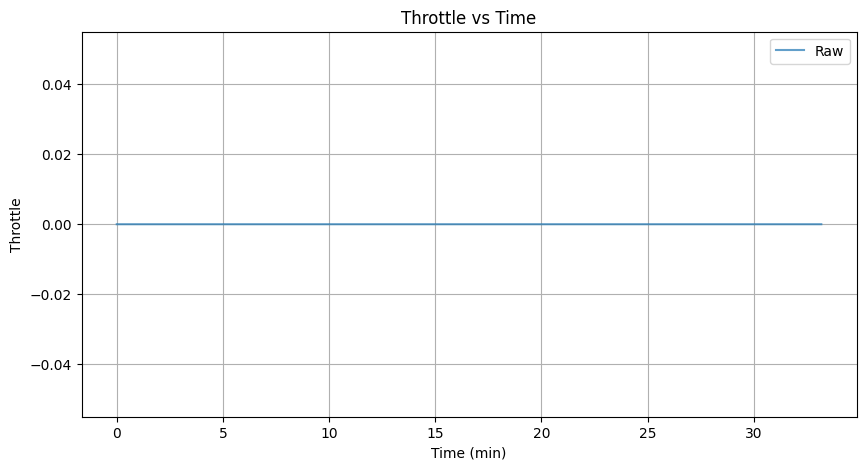

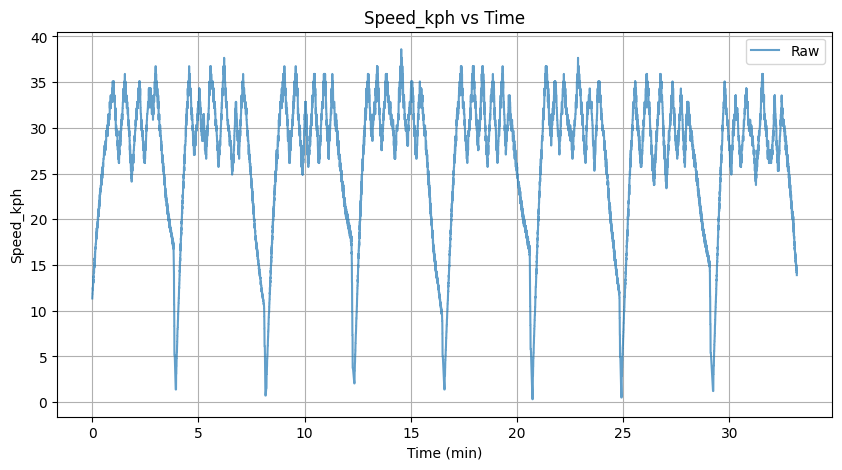

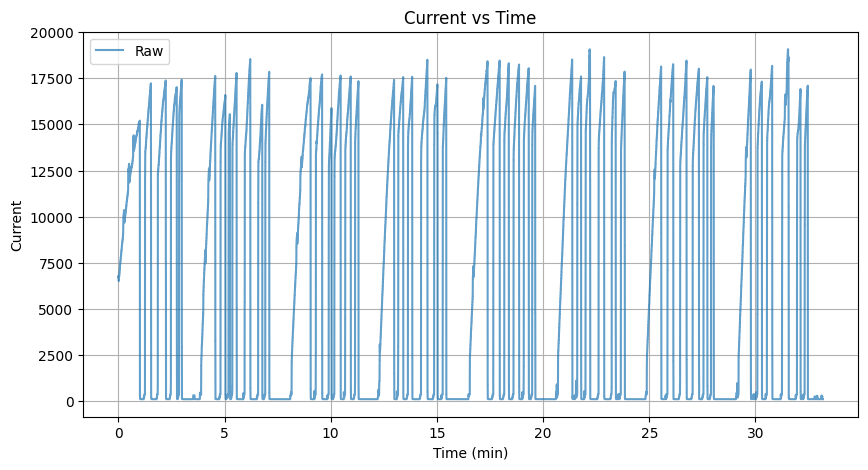

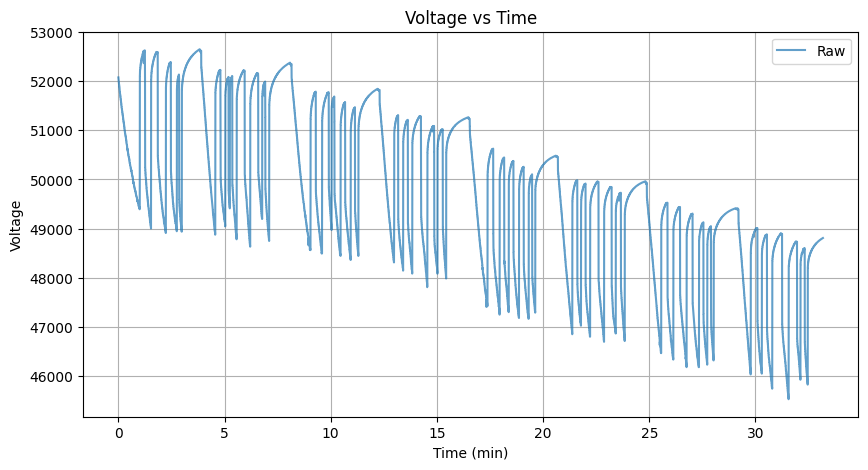

In [54]:
# Plot all columns
plotter.plot_all(smooth_window=0)

In [55]:
calc.get_efficiency(num_laps=2,energy_joules=267_844,track_len_km=TRACK_LEN)

Efficiency: 96772.75 km/kWh


In [56]:
calc.get_total_energy(plotter.data)


Total energy consumed: 611471.0375651681 J or 0.1698530659903245 kWh


# Track Map — IMS Grand Prix Road Course
Mapping **voltage**, **current draw**, and **car speed** onto the track layout.

| Parameter | Value |
|-----------|-------|
| Wheel diameter | 0.55 m |
| Encoder ticks/rev | 4 |
| Distance per tick | π × 0.55 / 4 ≈ 0.432 m |
| Track length | 3.875 km (15.5 / 4) |

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ── Physical parameters ──
WHEEL_DIAM = 0.55  # m
N_ENC = 4
CIRCUMFERENCE = np.pi * WHEEL_DIAM          # 1.7279 m
DIST_PER_TICK = CIRCUMFERENCE / N_ENC       # 0.4320 m
TRACK_LEN = 3832.5                          # metres (15.5/4 km)
SPEED_SCALE = 1.02  # scaling factor applied to raw speed (tune to match known lap distance)
CHOP_SECONDS = 0   # drop the first N seconds of data (e.g. pre-start idle)
START_COORDS = (39.792255, -86.238697)  # (lat, lon) — track origin for TrackPos = 0

# ── Process telemetry ──
df = plotter.data.copy()

# Chop leading data
if CHOP_SECONDS > 0:
    chop_ms = CHOP_SECONDS * 1000
    df = df[df['Tick'] >= chop_ms].copy()
    df['Tick'] = df['Tick'] - df['Tick'].iloc[0]   # re-zero after chop
    df['TimePlot'] = df['Tick'] / 60_000            # recalc minutes

# Recompute speed with scaling factor (raw Speed * 0.001 = kph before scaling)
df['Speed_kph'] = df['Speed'] * 0.001 * SPEED_SCALE
df['Speed_mps'] = df['Speed_kph'] / 3.6
df['Voltage_V'] = df['Voltage'] / 1000.0    # mV -> V
df['Current_A'] = df['Current'] / 1000.0    # mA -> A
df['dt'] = df['Tick'].diff().fillna(0) / 1000.0   # ms -> s
df['Distance_m'] = np.cumsum(df['Speed_mps'].values * df['dt'].values)
# TrackPos computed below after GPS track is loaded (needs arc-length for START_COORDS offset)

total_dist = df['Distance_m'].iloc[-1]
n_laps = total_dist / TRACK_LEN
print(f"Wheel dia: {WHEEL_DIAM} m | Circumference: {CIRCUMFERENCE:.4f} m")
print(f"Encoder ticks/rev: {N_ENC} | Distance/tick: {DIST_PER_TICK:.4f} m")
print(f"Speed scale: {SPEED_SCALE}")
if CHOP_SECONDS > 0:
    print(f"Chopped first {CHOP_SECONDS}s — {len(plotter.data) - len(df)} samples removed")
print(f"Total distance: {total_dist:.0f} m ({total_dist/1000:.2f} km)")
print(f"Laps completed: {n_laps:.2f}")
print(f"Max speed: {df['Speed_kph'].max():.1f} kph | "
      f"Avg moving speed: {df.loc[df['Speed_kph'] > 1, 'Speed_kph'].mean():.1f} kph")
print(f"Voltage: {df['Voltage_V'].min():.1f} - {df['Voltage_V'].max():.1f} V | "
      f"Current: {df['Current_A'].min():.1f} - {df['Current_A'].max():.1f} A")

# ── Load real GPS track centreline ──
track_gps = pd.read_csv('sem-us-2022-track_coordinates.csv')
gps_lat = track_gps.Latitude.values
gps_lon = track_gps.Longitude.values

# Convert GPS -> local XY (metres)
lat_ref = gps_lat.mean()
lon_ref = gps_lon.mean()
m_per_deg_lat = 110_540
m_per_deg_lon = 111_320 * np.cos(np.radians(lat_ref))
track_x = (gps_lon - lon_ref) * m_per_deg_lon
track_y = (gps_lat - lat_ref) * m_per_deg_lat
track_xy = np.column_stack([track_x, track_y])

# Arc-length along the GPS centreline
seg_lens = np.sqrt(np.sum(np.diff(track_xy, axis=0)**2, axis=1))
arc = np.zeros(len(track_xy))
arc[1:] = np.cumsum(seg_lens)
total_arc = arc[-1]

# ── Compute TrackPos with start-coordinate offset ──
_dists_to_start = (gps_lat - START_COORDS[0])**2 + (gps_lon - START_COORDS[1])**2
_start_idx = int(np.argmin(_dists_to_start))
_start_arc = arc[_start_idx]
START_OFFSET = (_start_arc / total_arc) * TRACK_LEN
df['TrackPos'] = (df['Distance_m'] + START_OFFSET) % TRACK_LEN
print(f"Start offset: {START_OFFSET:.1f} m (track point #{_start_idx}, "
      f"nearest to {START_COORDS})")

def dist_to_xy(d):
    """Map a track distance (m) to an (x, y) point on the GPS centreline."""
    arc_pos = (d / TRACK_LEN) * total_arc
    idx = min(np.searchsorted(arc, arc_pos % total_arc), len(track_xy) - 1)
    return track_xy[idx]

print(f"\nGPS track: {len(track_xy)} pts | arc = {total_arc:.0f} m")

Wheel dia: 0.55 m | Circumference: 1.7279 m
Encoder ticks/rev: 4 | Distance/tick: 0.4320 m
Speed scale: 1.02
Total distance: 15147 m (15.15 km)
Laps completed: 3.95
Max speed: 39.4 kph | Avg moving speed: 27.4 kph
Voltage: 45.5 - 52.7 V | Current: 0.1 - 19.1 A
Start offset: 28.9 m (track point #27, nearest to (39.792255, -86.238697))

GPS track: 3833 pts | arc = 3818 m


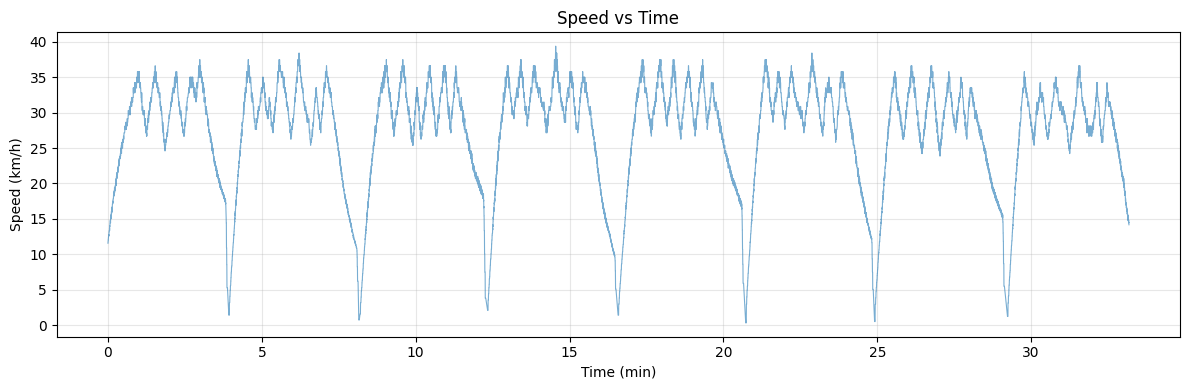

In [58]:
plt.figure(figsize=(12, 4))
plt.plot(df['TimePlot'], df['Speed_kph'], alpha=0.6, linewidth=0.8)
plt.xlabel('Time (min)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Efficiency Analysis

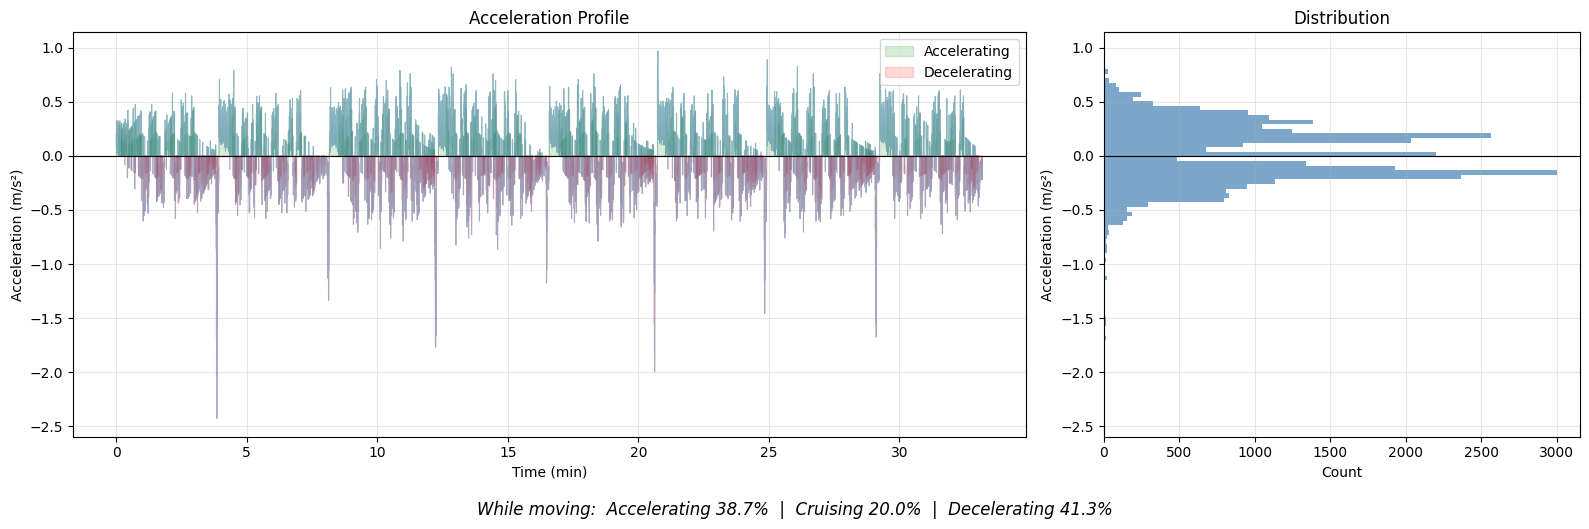

In [59]:
# ── Acceleration Profile ──
# Smooth speed to avoid amplifying sensor noise when differentiating
SMOOTH_W = 21  # rolling window size (odd number)
speed_smooth = df['Speed_mps'].rolling(SMOOTH_W, center=True, min_periods=1).mean()
accel = speed_smooth.diff() / df['dt']
accel = accel.fillna(0).clip(-5, 5)  # clip outliers from large dt gaps

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# Left — acceleration vs time
ax = axes[0]
ax.plot(df['TimePlot'], accel, alpha=0.5, linewidth=0.6, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(df['TimePlot'], accel, 0,
                where=accel > 0, alpha=0.15, color='green', label='Accelerating')
ax.fill_between(df['TimePlot'], accel, 0,
                where=accel < 0, alpha=0.15, color='red', label='Decelerating')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Acceleration (m/s²)')
ax.set_title('Acceleration Profile')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Right — histogram + time-share breakdown
ax2 = axes[1]
ax2.hist(accel[accel != 0], bins=80, orientation='horizontal',
         color='steelblue', alpha=0.7, edgecolor='none')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Count')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_title('Distribution')
ax2.grid(True, alpha=0.3)

# Time-share stats
moving = df['Speed_kph'] > 1  # ignore standstill
accel_moving = accel[moving]
t_accel = (accel_moving > 0.05).sum()
t_decel = (accel_moving < -0.05).sum()
t_cruise = ((accel_moving >= -0.05) & (accel_moving <= 0.05)).sum()
total = t_accel + t_decel + t_cruise
if total > 0:
    fig.text(0.5, -0.04,
             f'While moving:  Accelerating {t_accel/total*100:.1f}%  |  '
             f'Cruising {t_cruise/total*100:.1f}%  |  '
             f'Decelerating {t_decel/total*100:.1f}%',
             ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

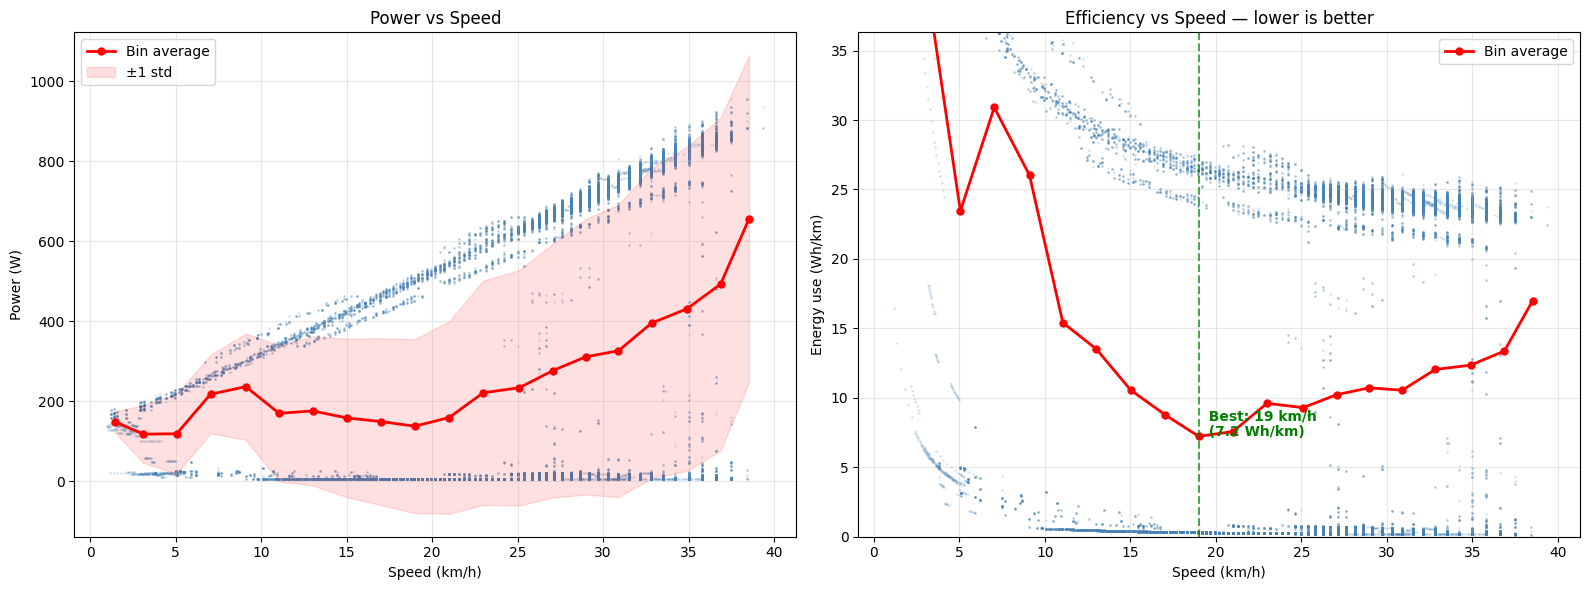

In [60]:
# ── Power vs Speed Scatter ──
df['Power_W'] = df['Voltage_V'] * df['Current_A']

# Filter to moving samples only
mask = df['Speed_kph'] > 1
spd_mov = df.loc[mask, 'Speed_kph']
pwr_mov = df.loc[mask, 'Power_W']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — raw scatter with binned average curve
ax = axes[0]
ax.scatter(spd_mov, pwr_mov, s=1, alpha=0.15, color='steelblue', rasterized=True)

# Bin averages to show the trend (drag curve)
speed_bins = np.arange(0, spd_mov.max() + 2, 2)  # 2 kph bins
bin_idx = np.digitize(spd_mov, speed_bins) - 1
bin_means = pd.DataFrame({'spd': spd_mov, 'pwr': pwr_mov, 'bin': bin_idx}) \
              .groupby('bin').agg(spd_mean=('spd', 'mean'), pwr_mean=('pwr', 'mean'),
                                  pwr_std=('pwr', 'std'), count=('pwr', 'count'))
bin_means = bin_means[bin_means['count'] >= 10]  # require enough samples
ax.plot(bin_means['spd_mean'], bin_means['pwr_mean'],
        'o-', color='red', linewidth=2, markersize=5, label='Bin average')
ax.fill_between(bin_means['spd_mean'],
                bin_means['pwr_mean'] - bin_means['pwr_std'],
                bin_means['pwr_mean'] + bin_means['pwr_std'],
                color='red', alpha=0.12, label='±1 std')
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Power (W)')
ax.set_title('Power vs Speed')
ax.legend()
ax.grid(True, alpha=0.3)

# Right — Wh/km vs speed (instantaneous efficiency)
# Wh/km = Power_W / (Speed_m/s * 1000) * 1000  =  P / (v * 1000) * 1000  =  P / v
# More precisely: Wh/km = (W) / (km/h) = W·h/km
# Energy rate = P (W = J/s), distance rate = v (km/h = km/3600s)
# Wh/km = P / (v/3.6) / 1000  ... let's just compute it carefully:
# Wh/km = P(W) / v(m/s) / 1000   (since W/(m/s) = J/m, / 1000 = J/mm ... no)
# Wh/km = P(W) / (v(km/h)) * 1  since P is J/s and v is km/3600s:
#   energy per km = P / (v/3.6) J/m  = P*3.6/v J/m  * 1000 = P*3600/v J/km  / 3600 = P/v Wh/km
whpkm = pwr_mov / spd_mov  # Wh/km
ax2 = axes[1]
ax2.scatter(spd_mov, whpkm, s=1, alpha=0.15, color='steelblue', rasterized=True)

# Bin averages
bin_eff = pd.DataFrame({'spd': spd_mov, 'eff': whpkm, 'bin': bin_idx}) \
            .groupby('bin').agg(spd_mean=('spd', 'mean'), eff_mean=('eff', 'mean'),
                                count=('eff', 'count'))
bin_eff = bin_eff[bin_eff['count'] >= 10]
ax2.plot(bin_eff['spd_mean'], bin_eff['eff_mean'],
         'o-', color='red', linewidth=2, markersize=5, label='Bin average')

# Mark the optimal speed (minimum Wh/km)
if len(bin_eff) > 0:
    best = bin_eff.loc[bin_eff['eff_mean'].idxmin()]
    ax2.axvline(best['spd_mean'], color='green', linestyle='--', alpha=0.7)
    ax2.annotate(f"  Best: {best['spd_mean']:.0f} km/h\n  ({best['eff_mean']:.1f} Wh/km)",
                 xy=(best['spd_mean'], best['eff_mean']),
                 fontsize=10, fontweight='bold', color='green')

ax2.set_xlabel('Speed (km/h)')
ax2.set_ylabel('Energy use (Wh/km)')
ax2.set_title('Efficiency vs Speed — lower is better')
ax2.set_ylim(0, np.percentile(whpkm, 95) * 1.3)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Lap-by-lap speed stats (while moving):
 Lap  Avg (kph)  Std (kph)  CV (%)  Min (kph)  Max (kph)
   1       27.0        7.9    29.4        1.0       38.4
   2       27.5        8.2    30.0        1.4       39.4
   3       27.8        7.8    28.0        1.0       38.4

A lower CV% means steadier speed → less energy wasted on drag variation.


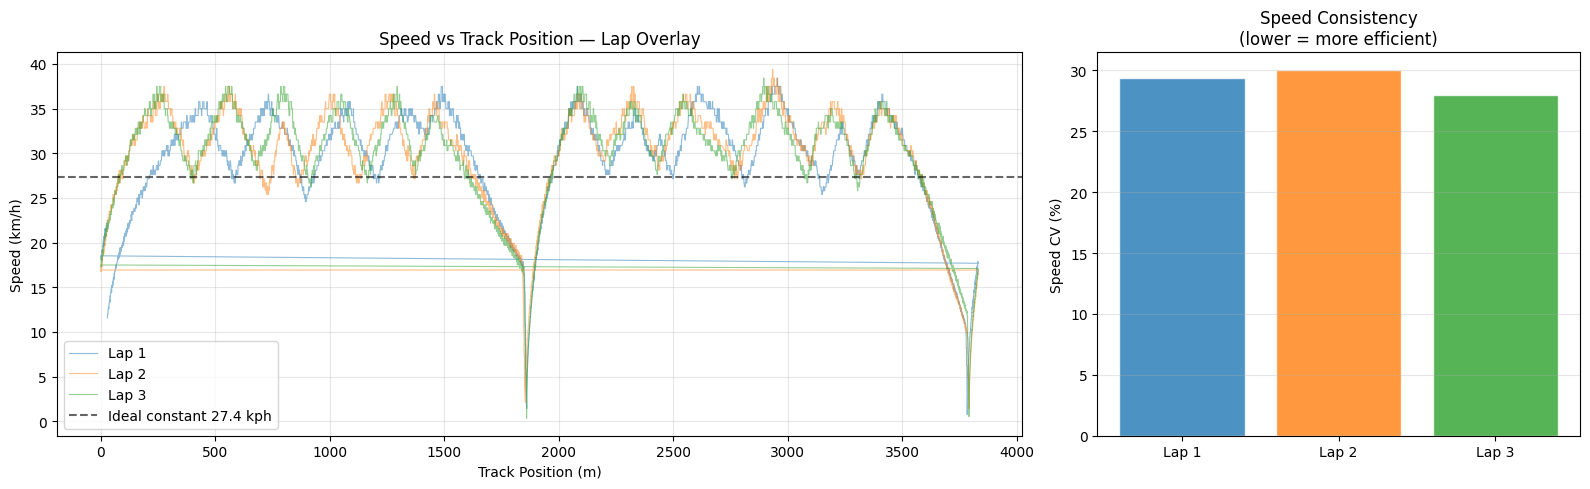

In [61]:
# ── Speed Variance per Lap ──
# Trim to the 2nd drop-to-zero: 1st zero is the initial standstill ending,
# 2nd zero marks the real end-of-run stop. Anything beyond is idle noise
# that distorts lap counting and inter-lap stats.
lap_df_full = df.copy()
_stopped = lap_df_full['Speed_kph'] < 0.5
_drop_mask = _stopped & ~_stopped.shift(1, fill_value=False)
_drops = lap_df_full.index[_drop_mask].tolist()
if len(_drops) >= 2:
    lap_df_full = lap_df_full.loc[:_drops[1]].copy()
    print(f"Trimmed at 2nd drop-to-zero (idx {_drops[1]}); {len(_drops)} drops total")
else:
    print(f"Only {len(_drops)} drop(s) to zero — using full data")

lap_df_full['Lap'] = (lap_df_full['Distance_m'] / TRACK_LEN).astype(int)
completed_laps = sorted(lap_df_full['Lap'].unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# Left — speed vs track position, one trace per lap
ax = axes[0]
colors = plt.cm.tab10.colors
stats_rows = []

for j, lap_num in enumerate(completed_laps):
    lap_df = lap_df_full[lap_df_full['Lap'] == lap_num]
    pos = lap_df['TrackPos']
    spd = lap_df['Speed_kph']
    c = colors[j % len(colors)]
    ax.plot(pos, spd, alpha=0.5, linewidth=0.8, color=c, label=f'Lap {lap_num + 1}')

    # Compute stats for this lap
    moving = spd[spd > 1]
    stats_rows.append({
        'Lap': lap_num + 1,
        'Avg (kph)': moving.mean(),
        'Std (kph)': moving.std(),
        'CV (%)': moving.std() / moving.mean() * 100 if moving.mean() > 0 else 0,
        'Min (kph)': moving.min() if len(moving) > 0 else 0,
        'Max (kph)': moving.max() if len(moving) > 0 else 0,
    })

# Ideal constant-speed reference
if stats_rows:
    avg_all = np.mean([r['Avg (kph)'] for r in stats_rows])
    ax.axhline(avg_all, color='black', linestyle='--', linewidth=1.5,
               alpha=0.6, label=f'Ideal constant {avg_all:.1f} kph')

ax.set_xlabel('Track Position (m)')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed vs Track Position — Lap Overlay')
ax.legend()
ax.grid(True, alpha=0.3)

# Right — bar chart of coefficient of variation per lap
ax2 = axes[1]
if stats_rows:
    lap_labels = [f'Lap {r["Lap"]}' for r in stats_rows]
    cvs = [r['CV (%)'] for r in stats_rows]
    bar_colors = [colors[j % len(colors)] for j in range(len(stats_rows))]
    bars = ax2.bar(lap_labels, cvs, color=bar_colors, alpha=0.8, edgecolor='white')
    ax2.set_ylabel('Speed CV (%)')
    ax2.set_title('Speed Consistency\n(lower = more efficient)')
    ax2.grid(True, alpha=0.3, axis='y')

    # Print stats table
    stats_df = pd.DataFrame(stats_rows).round(1)
    print("Lap-by-lap speed stats (while moving):")
    print(stats_df.to_string(index=False))
    print(f"\nA lower CV% means steadier speed → less energy wasted on drag variation.")

plt.tight_layout()
plt.show()

# Energy-Optimal Driving Strategy
Simplified model: no aero drag, no rolling resistance, no regenerative braking.  
Motor energy = kinetic energy (acceleration) + potential energy (uphill climbs).

Elevation mapped: 219.00 – 222.74 m (range 3.74 m)
Mass: 164.0 kg | Accel: 0.35 m/s² | Decel: 0.3 m/s²
Segments: ['1800m', '1900m', '132m']

Optimal cruise speed: 10.80 m/s (38.9 km/h)
  Seg 1: 1800m | trap | cruise 38.9 km/h | 200.1s
  Seg 2: 1900m | trap | cruise 38.9 km/h | 209.4s
  Seg 3: 132m | tri | peak 23.6 km/h (no cruise) | 40.5s
  Lap time: 450.0s × 4 laps = 1800s / 1800s budget

Energy per lap: 30339 J (8.4 Wh)
Energy 4 laps:  121354 J (33.7 Wh)
Efficiency:     454.8 km/kWh

  KE per cruise stop: 9560 J (2.66 Wh)
  KE per short stop:  3510 J (0.97 Wh) @ 23.6 km/h
  PE (uphills/lap):   7708 J (2.14 Wh)


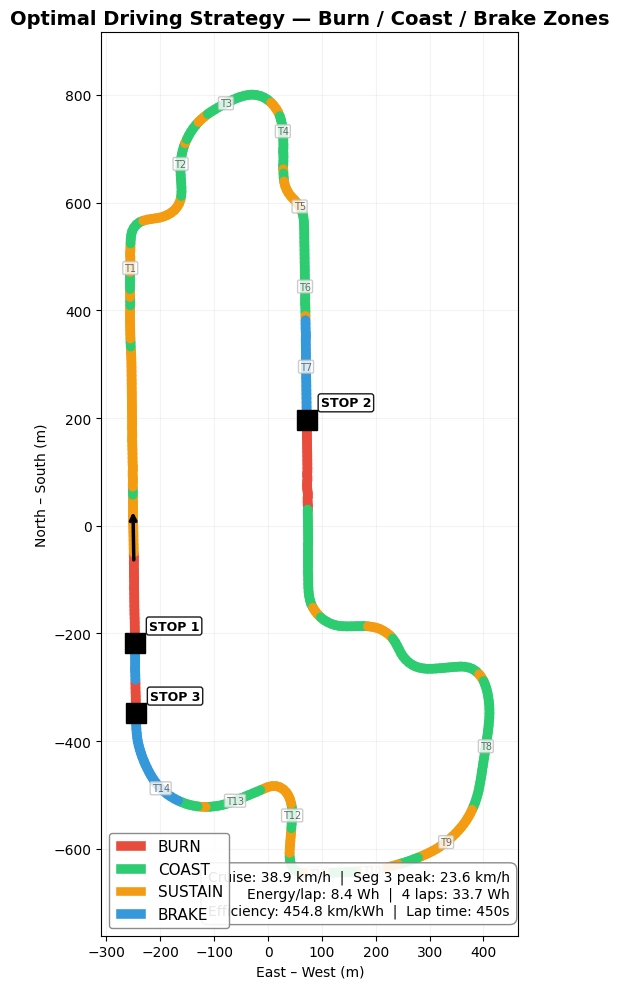

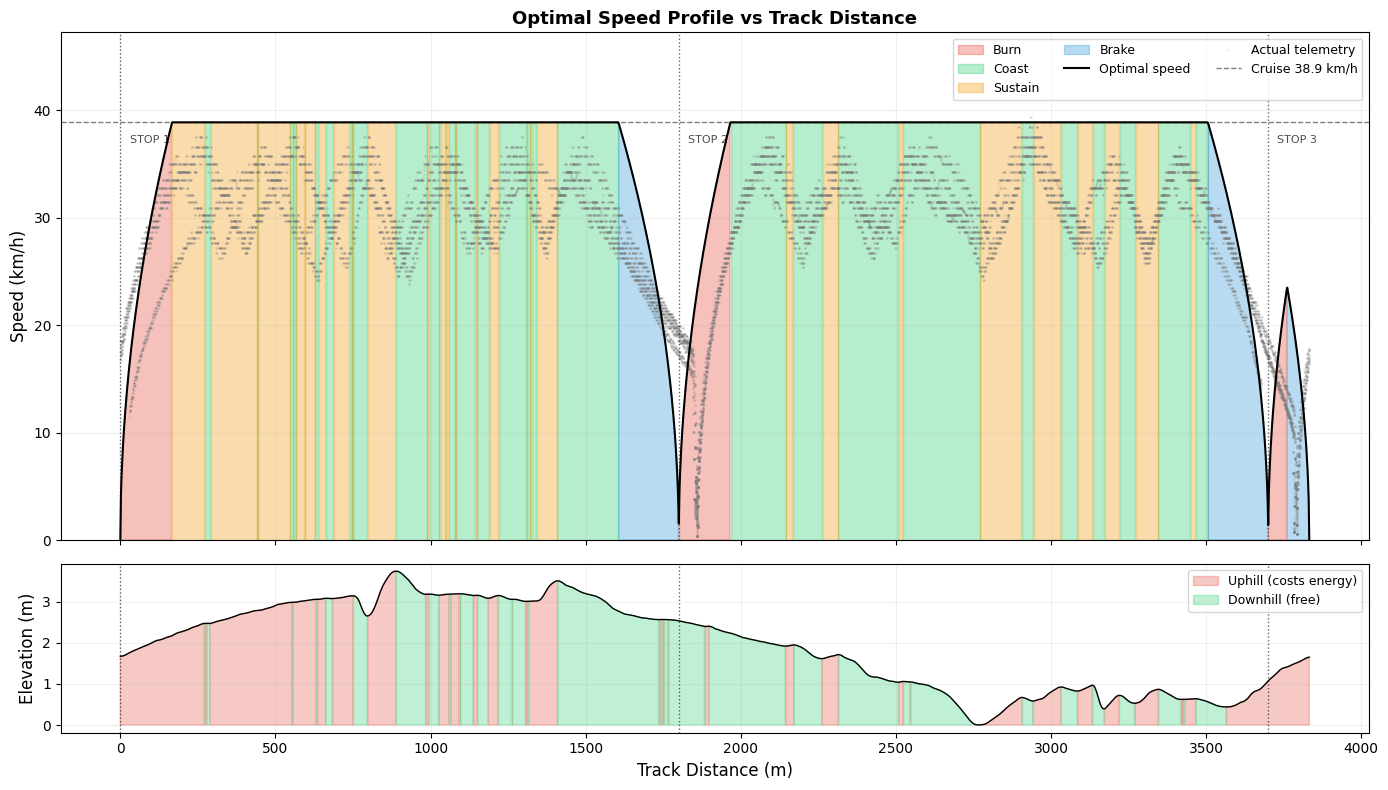

  OPTIMAL DRIVING STRATEGY SUMMARY
  Vehicle mass:       164.0 kg
  Optimal cruise:     38.9 km/h (10.80 m/s)
  Segment 1 (1800m):   burn 167m → coast 1439m → brake 194m  [200.1s]
  Segment 2 (1900m):   burn 167m → coast 1539m → brake 194m  [209.4s]
  Segment 3 (132m):   burn 61m → immediately 0m → brake 71m  [40.5s]
  Lap time:           450.0s × 4 = 1800s
  Energy/lap:         8.4 Wh  (KE: 6.3 Wh + PE: 2.1 Wh)
  Energy total:       33.7 Wh
  Efficiency:         454.8 km/kWh
-----------------------------------------------------------------
  ⚠ Theoretical minimum — real energy is higher due to drag,
    rolling resistance, motor/controller inefficiency, etc.


In [62]:
# ── Energy-Optimal Driving Strategy ──
from matplotlib.patches import Patch

# ================================================================
# Section 1 — Map elevation from sem_2023_us.csv onto track distance
# ================================================================
elev_df = pd.read_csv('sem_2023_us.csv')
elev_lat = elev_df['Latitude'].values
elev_lon = elev_df['Longitude'].values
elev_raw_vals = elev_df['Metres above sea level'].values

# Nearest-neighbour: for each 2022 track point, find closest 2023 elevation point
# Use chunked approach to avoid large memory allocation
nn_idx = np.empty(len(gps_lat), dtype=int)
CHUNK = 500
for start in range(0, len(gps_lat), CHUNK):
    end = min(start + CHUNK, len(gps_lat))
    dlat = gps_lat[start:end, None] - elev_lat[None, :]
    dlon = gps_lon[start:end, None] - elev_lon[None, :]
    nn_idx[start:end] = np.argmin(dlat**2 + dlon**2, axis=1)

elev_on_track_raw = elev_raw_vals[nn_idx]

# Track distance for each of the 3833 GPS points
elev_track_dist = arc / total_arc * TRACK_LEN

# Smooth elevation to remove NN artifacts
elev_smooth = pd.Series(elev_on_track_raw).rolling(21, center=True, min_periods=1).mean().values

def elev_at_d(d):
    """Interpolate elevation at any track distance."""
    return np.interp(d, elev_track_dist, elev_smooth)

print(f"Elevation mapped: {elev_smooth.min():.2f} – {elev_smooth.max():.2f} m "
      f"(range {elev_smooth.max() - elev_smooth.min():.2f} m)")

# ================================================================
# Section 2 — Physical constants & segment definitions
# ================================================================
MASS_KG = (205 + 156.528) * 0.453592    # lbs → kg ≈ 164 kg
G = 9.81                                 # m/s²
A_ACC = 0.35                             # m/s² (from telemetry)
A_DEC = 0.30                             # m/s² (from telemetry)
V_MAX = 12.5                             # m/s (45 km/h)
N_LAPS = 4
TOTAL_TIME = 1800                        # s (30 min)
TIME_PER_LAP = TOTAL_TIME / N_LAPS       # 450 s

# Mandatory stop positions (track distance, metres) — editable
STOP_POS = [0, 1800, 3700]
# Close the loop
STOP_POS_FULL = STOP_POS + [TRACK_LEN]
SEG_LENGTHS = [STOP_POS_FULL[i+1] - STOP_POS_FULL[i] for i in range(len(STOP_POS))]

print(f"Mass: {MASS_KG:.1f} kg | Accel: {A_ACC} m/s² | Decel: {A_DEC} m/s²")
print(f"Segments: {[f'{L:.0f}m' for L in SEG_LENGTHS]}")

# ================================================================
# Section 3 — Solve for optimal cruise speed
# ================================================================

def seg_time(L, v, a_acc=A_ACC, a_dec=A_DEC):
    """Time for a trapezoidal (accel→cruise→decel) segment of length L at cruise speed v."""
    d_acc = v**2 / (2 * a_acc)
    d_dec = v**2 / (2 * a_dec)
    if d_acc + d_dec > L:
        return None  # can't reach v — need triangular profile
    t_acc = v / a_acc
    t_dec = v / a_dec
    t_cruise = (L - d_acc - d_dec) / v
    return t_acc + t_cruise + t_dec

def tri_peak(L, a_acc=A_ACC, a_dec=A_DEC):
    """Peak speed & time for a triangular profile (accel then immediately decel) over distance L."""
    # L = v²/(2·a_acc) + v²/(2·a_dec)  →  v = sqrt(L / (1/(2a) + 1/(2d)))
    v = np.sqrt(L / (1/(2*a_acc) + 1/(2*a_dec)))
    t = v / a_acc + v / a_dec
    return v, t

# Check each segment: can it sustain a cruise phase, or is it triangular-only?
seg_profiles = []
for i, L in enumerate(SEG_LENGTHS):
    v_tri, t_tri = tri_peak(L)
    if v_tri < V_MAX:
        seg_profiles.append(('tri', v_tri, t_tri, L))
    else:
        seg_profiles.append(('trap', None, None, L))  # cruise speed TBD

# Time consumed by triangular (short) segments
t_fixed = sum(t for kind, v, t, L in seg_profiles if kind == 'tri')
trap_segs = [(i, L) for i, (kind, v, t, L) in enumerate(seg_profiles) if kind == 'trap']
t_budget_trap = TIME_PER_LAP - t_fixed

# Binary search for minimum cruise speed across trapezoidal segments
if trap_segs:
    v_lo, v_hi = 0.1, V_MAX
    for _ in range(100):
        v_mid = (v_lo + v_hi) / 2
        t_total = sum(seg_time(L, v_mid) or float('inf') for _, L in trap_segs)
        if t_total > t_budget_trap:
            v_lo = v_mid
        else:
            v_hi = v_mid
    v_cruise = v_hi
    # Fill in the trapezoidal segments
    for idx, L in trap_segs:
        kind, _, _, _ = seg_profiles[idx]
        seg_profiles[idx] = ('trap', v_cruise, seg_time(L, v_cruise), L)
else:
    v_cruise = 0  # all segments are triangular

# Verify total lap time
lap_time = sum(t for _, _, t, _ in seg_profiles)
print(f"\nOptimal cruise speed: {v_cruise:.2f} m/s ({v_cruise*3.6:.1f} km/h)")
for i, (kind, v, t, L) in enumerate(seg_profiles):
    tag = f"cruise {v*3.6:.1f} km/h" if kind == 'trap' else f"peak {v*3.6:.1f} km/h (no cruise)"
    print(f"  Seg {i+1}: {L:.0f}m | {kind} | {tag} | {t:.1f}s")
print(f"  Lap time: {lap_time:.1f}s × {N_LAPS} laps = {lap_time*N_LAPS:.0f}s / {TOTAL_TIME}s budget")

# ================================================================
# Section 4 — Build speed profile & classify zones
# ================================================================
N_PTS = 2000
d_arr = np.linspace(0, TRACK_LEN, N_PTS)
v_arr = np.zeros(N_PTS)
zone_arr = np.zeros(N_PTS, dtype=int)  # 0=BURN, 1=COAST, 2=SUSTAIN(uphill), 3=BRAKE

# Zone boundaries for each segment
zone_bounds = []  # list of (d_start, d_end, zone_type, v_start, v_end)
for i, (kind, v_peak, t_seg, L) in enumerate(seg_profiles):
    d0 = STOP_POS_FULL[i]
    d1 = STOP_POS_FULL[i + 1]
    d_acc = v_peak**2 / (2 * A_ACC)
    d_dec = v_peak**2 / (2 * A_DEC)
    if kind == 'trap':
        zone_bounds.append((d0, d0 + d_acc, 0, 0, v_peak))              # BURN
        zone_bounds.append((d0 + d_acc, d1 - d_dec, 1, v_peak, v_peak)) # COAST (refined below)
        zone_bounds.append((d1 - d_dec, d1, 3, v_peak, 0))              # BRAKE
    else:  # triangular
        zone_bounds.append((d0, d0 + d_acc, 0, 0, v_peak))              # BURN
        zone_bounds.append((d0 + d_acc, d1, 3, v_peak, 0))              # BRAKE

# Compute speed at each point
for d_start, d_end, zone, v_s, v_e in zone_bounds:
    mask = (d_arr >= d_start) & (d_arr < d_end)
    dd = d_arr[mask] - d_start
    L_zone = d_end - d_start
    if zone == 0:  # BURN
        v_arr[mask] = np.sqrt(np.clip(2 * A_ACC * dd, 0, None))
    elif zone == 3:  # BRAKE
        dd_from_end = d_end - d_arr[mask]
        v_arr[mask] = np.sqrt(np.clip(2 * A_DEC * dd_from_end, 0, None))
    else:  # COAST
        v_arr[mask] = v_s
    zone_arr[mask] = zone

# Refine COAST zones: check elevation gradient to split into COAST vs SUSTAIN
elev_arr = elev_at_d(d_arr)
grade = np.gradient(elev_arr, d_arr)  # dh/dx (dimensionless slope)
for idx in range(N_PTS):
    if zone_arr[idx] == 1:  # currently COAST
        if grade[idx] > 0.0005:  # uphill threshold (~0.05% grade)
            zone_arr[idx] = 2  # SUSTAIN — motor needed

# ── Energy calculation ──
dd = np.diff(d_arr, prepend=d_arr[0])
dh = np.diff(elev_arr, prepend=elev_arr[0])
dv = np.diff(v_arr, prepend=0)

energy_arr = np.zeros(N_PTS)
for idx in range(N_PTS):
    if zone_arr[idx] == 0:  # BURN — motor supplies KE
        energy_arr[idx] = max(0, MASS_KG * v_arr[idx] * dv[idx])
    elif zone_arr[idx] == 2:  # SUSTAIN — motor supplies PE to maintain speed uphill
        energy_arr[idx] = max(0, MASS_KG * G * dh[idx])
energy_cum = np.cumsum(energy_arr)
energy_per_lap = energy_cum[-1]
energy_total = energy_per_lap * N_LAPS
dist_total = TRACK_LEN * N_LAPS / 1000  # km
eff_km_kwh = dist_total / (energy_total / 3.6e6) if energy_total > 0 else float('inf')

print(f"\nEnergy per lap: {energy_per_lap:.0f} J ({energy_per_lap/3600:.1f} Wh)")
print(f"Energy 4 laps:  {energy_total:.0f} J ({energy_total/3600:.1f} Wh)")
print(f"Efficiency:     {eff_km_kwh:.1f} km/kWh")

# KE breakdown
ke_per_stop = 0.5 * MASS_KG * v_cruise**2
ke_seg3 = 0.5 * MASS_KG * seg_profiles[-1][1]**2 if seg_profiles[-1][0] == 'tri' else ke_per_stop
n_trap_stops = len(trap_segs) if trap_segs else 0
n_tri_stops = len(seg_profiles) - n_trap_stops
ke_total_lap = n_trap_stops * ke_per_stop + n_tri_stops * ke_seg3
pe_total_lap = energy_per_lap - ke_total_lap

print(f"\n  KE per cruise stop: {ke_per_stop:.0f} J ({ke_per_stop/3600:.2f} Wh)")
if n_tri_stops > 0:
    v_tri_val = seg_profiles[-1][1]
    print(f"  KE per short stop:  {ke_seg3:.0f} J ({ke_seg3/3600:.2f} Wh) @ {v_tri_val*3.6:.1f} km/h")
print(f"  PE (uphills/lap):   {pe_total_lap:.0f} J ({pe_total_lap/3600:.2f} Wh)")

# ================================================================
# Section 5 — Track map colored by driving zone
# ================================================================
ZONE_COLORS = ['#E74C3C', '#2ECC71', '#F39C12', '#3498DB']
ZONE_NAMES  = ['BURN', 'COAST', 'SUSTAIN', 'BRAKE']
zone_cmap = plt.matplotlib.colors.ListedColormap(ZONE_COLORS)
zone_norm = plt.matplotlib.colors.BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], zone_cmap.N)

# Build 500 evenly-spaced points on track (self-contained, doesn't need cell 12)
N_MAP = 500
map_dists = np.linspace(0, TRACK_LEN, N_MAP)
map_xy = np.array([dist_to_xy(d) for d in map_dists])
map_pts = map_xy.reshape(-1, 1, 2)
map_segs = np.concatenate([map_pts[:-1], map_pts[1:]], axis=1)

# Zone label at each map point
map_zones = np.interp(map_dists, d_arr, zone_arr.astype(float))
map_zones = np.round(map_zones).astype(int)

# Turn labels
_turn_info = [
    ('T1',  700), ('T2',  950), ('T3', 1100), ('T4', 1250),
    ('T5', 1400), ('T6', 1550), ('T7', 1700),
    ('T8', 2650), ('T9', 2850), ('T10', 3000),
    ('T11', 3100), ('T12', 3250), ('T13', 3400), ('T14', 3550),
]

fig_map, ax_map = plt.subplots(1, 1, figsize=(12, 10))

lc = LineCollection(map_segs, cmap=zone_cmap, norm=zone_norm,
                    linewidths=7, capstyle='round')
lc.set_array(map_zones[:-1].astype(float))
ax_map.add_collection(lc)

# Stop point markers
for j, sp in enumerate(STOP_POS):
    sxy = dist_to_xy(sp)
    ax_map.plot(*sxy, 's', color='black', ms=14, zorder=6)
    ax_map.annotate(f'STOP {j+1}', sxy, textcoords='offset points',
                    xytext=(10, 10), fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', alpha=0.9))

# Direction arrow
a1, a2 = dist_to_xy(150), dist_to_xy(250)
ax_map.annotate('', xy=a2, xytext=a1,
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

# Turn labels
for lbl, d in _turn_info:
    txy = dist_to_xy(d)
    ax_map.annotate(lbl, txy, fontsize=7, ha='center', va='center',
                    color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.15',
                              fc='white', ec='silver', alpha=0.8))

# Legend
legend_patches = [Patch(facecolor=c, edgecolor='white', label=n)
                  for c, n in zip(ZONE_COLORS, ZONE_NAMES)]
ax_map.legend(handles=legend_patches, loc='lower left', fontsize=11,
              framealpha=0.9, edgecolor='grey')

# Stats text box
stats_text = (
    f"Cruise: {v_cruise*3.6:.1f} km/h  |  "
    f"Seg 3 peak: {seg_profiles[-1][1]*3.6:.1f} km/h\n"
    f"Energy/lap: {energy_per_lap/3600:.1f} Wh  |  "
    f"4 laps: {energy_total/3600:.1f} Wh\n"
    f"Efficiency: {eff_km_kwh:.1f} km/kWh  |  "
    f"Lap time: {lap_time:.0f}s"
)
ax_map.text(0.98, 0.02, stats_text, transform=ax_map.transAxes,
            fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.9, edgecolor='grey'))

ax_map.set_aspect('equal')
ax_map.set_title('Optimal Driving Strategy — Burn / Coast / Brake Zones',
                 fontsize=14, fontweight='bold')
ax_map.set_xlabel('East – West (m)')
ax_map.set_ylabel('North – South (m)')
ax_map.grid(True, alpha=0.15)
ax_map.autoscale()
ax_map.margins(0.08)
plt.tight_layout()
plt.show()

# ================================================================
# Section 6 — Speed profile + elevation (2-panel figure)
# ================================================================
fig_prof, (ax_spd, ax_elev) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]})

# ── Top panel: speed vs track distance ──
# Colored fill by zone
for z, color, name in [(0, '#E74C3C', 'Burn'), (1, '#2ECC71', 'Coast'),
                        (2, '#F39C12', 'Sustain'), (3, '#3498DB', 'Brake')]:
    mask = zone_arr == z
    ax_spd.fill_between(d_arr, 0, v_arr * 3.6, where=mask,
                        color=color, alpha=0.35, label=name)

ax_spd.plot(d_arr, v_arr * 3.6, 'k-', linewidth=1.5, label='Optimal speed')

# Overlay actual telemetry (scatter, low alpha)
ax_spd.scatter(df['TrackPos'].values, df['Speed_kph'].values,
               s=1, alpha=0.08, color='grey', label='Actual telemetry', rasterized=True)

# Cruise speed reference
if v_cruise > 0:
    ax_spd.axhline(v_cruise * 3.6, color='black', ls='--', lw=1, alpha=0.5,
                   label=f'Cruise {v_cruise*3.6:.1f} km/h')

# Stop position lines
for j, sp in enumerate(STOP_POS):
    ax_spd.axvline(sp, color='black', ls=':', lw=1, alpha=0.6)
    ax_spd.text(sp + 30, v_cruise * 3.6 * 0.95, f'STOP {j+1}',
                fontsize=8, color='black', alpha=0.7)

ax_spd.set_ylabel('Speed (km/h)', fontsize=12)
ax_spd.set_ylim(0, V_MAX * 3.6 * 1.05)
ax_spd.legend(loc='upper right', fontsize=9, ncol=3)
ax_spd.grid(True, alpha=0.2)
ax_spd.set_title('Optimal Speed Profile vs Track Distance', fontsize=13, fontweight='bold')

# ── Bottom panel: elevation profile ──
elev_plot = elev_at_d(d_arr)
elev_rel = elev_plot - elev_plot.min()
grade_plot = np.gradient(elev_plot, d_arr)

ax_elev.fill_between(d_arr, 0, elev_rel, where=grade_plot >= 0,
                     color='#E74C3C', alpha=0.3, label='Uphill (costs energy)')
ax_elev.fill_between(d_arr, 0, elev_rel, where=grade_plot < 0,
                     color='#2ECC71', alpha=0.3, label='Downhill (free)')
ax_elev.plot(d_arr, elev_rel, 'k-', linewidth=1)

for j, sp in enumerate(STOP_POS):
    ax_elev.axvline(sp, color='black', ls=':', lw=1, alpha=0.6)

ax_elev.set_xlabel('Track Distance (m)', fontsize=12)
ax_elev.set_ylabel('Elevation (m)', fontsize=12)
ax_elev.legend(loc='upper right', fontsize=9)
ax_elev.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ================================================================
# Summary
# ================================================================
print("=" * 65)
print("  OPTIMAL DRIVING STRATEGY SUMMARY")
print("=" * 65)
print(f"  Vehicle mass:       {MASS_KG:.1f} kg")
print(f"  Optimal cruise:     {v_cruise*3.6:.1f} km/h ({v_cruise:.2f} m/s)")
for i, (kind, v, t, L) in enumerate(seg_profiles):
    d_acc_i = v**2 / (2*A_ACC)
    d_dec_i = v**2 / (2*A_DEC)
    d_coast_i = max(0, L - d_acc_i - d_dec_i)
    print(f"  Segment {i+1} ({L:.0f}m):   "
          f"burn {d_acc_i:.0f}m → {'coast' if kind=='trap' else 'immediately'} "
          f"{d_coast_i:.0f}m → brake {d_dec_i:.0f}m  [{t:.1f}s]")
print(f"  Lap time:           {lap_time:.1f}s × {N_LAPS} = {lap_time*N_LAPS:.0f}s")
print(f"  Energy/lap:         {energy_per_lap/3600:.1f} Wh  "
      f"(KE: {ke_total_lap/3600:.1f} Wh + PE: {pe_total_lap/3600:.1f} Wh)")
print(f"  Energy total:       {energy_total/3600:.1f} Wh")
print(f"  Efficiency:         {eff_km_kwh:.1f} km/kWh")
print("-" * 65)
print("  ⚠ Theoretical minimum — real energy is higher due to drag,")
print("    rolling resistance, motor/controller inefficiency, etc.")
print("=" * 65)


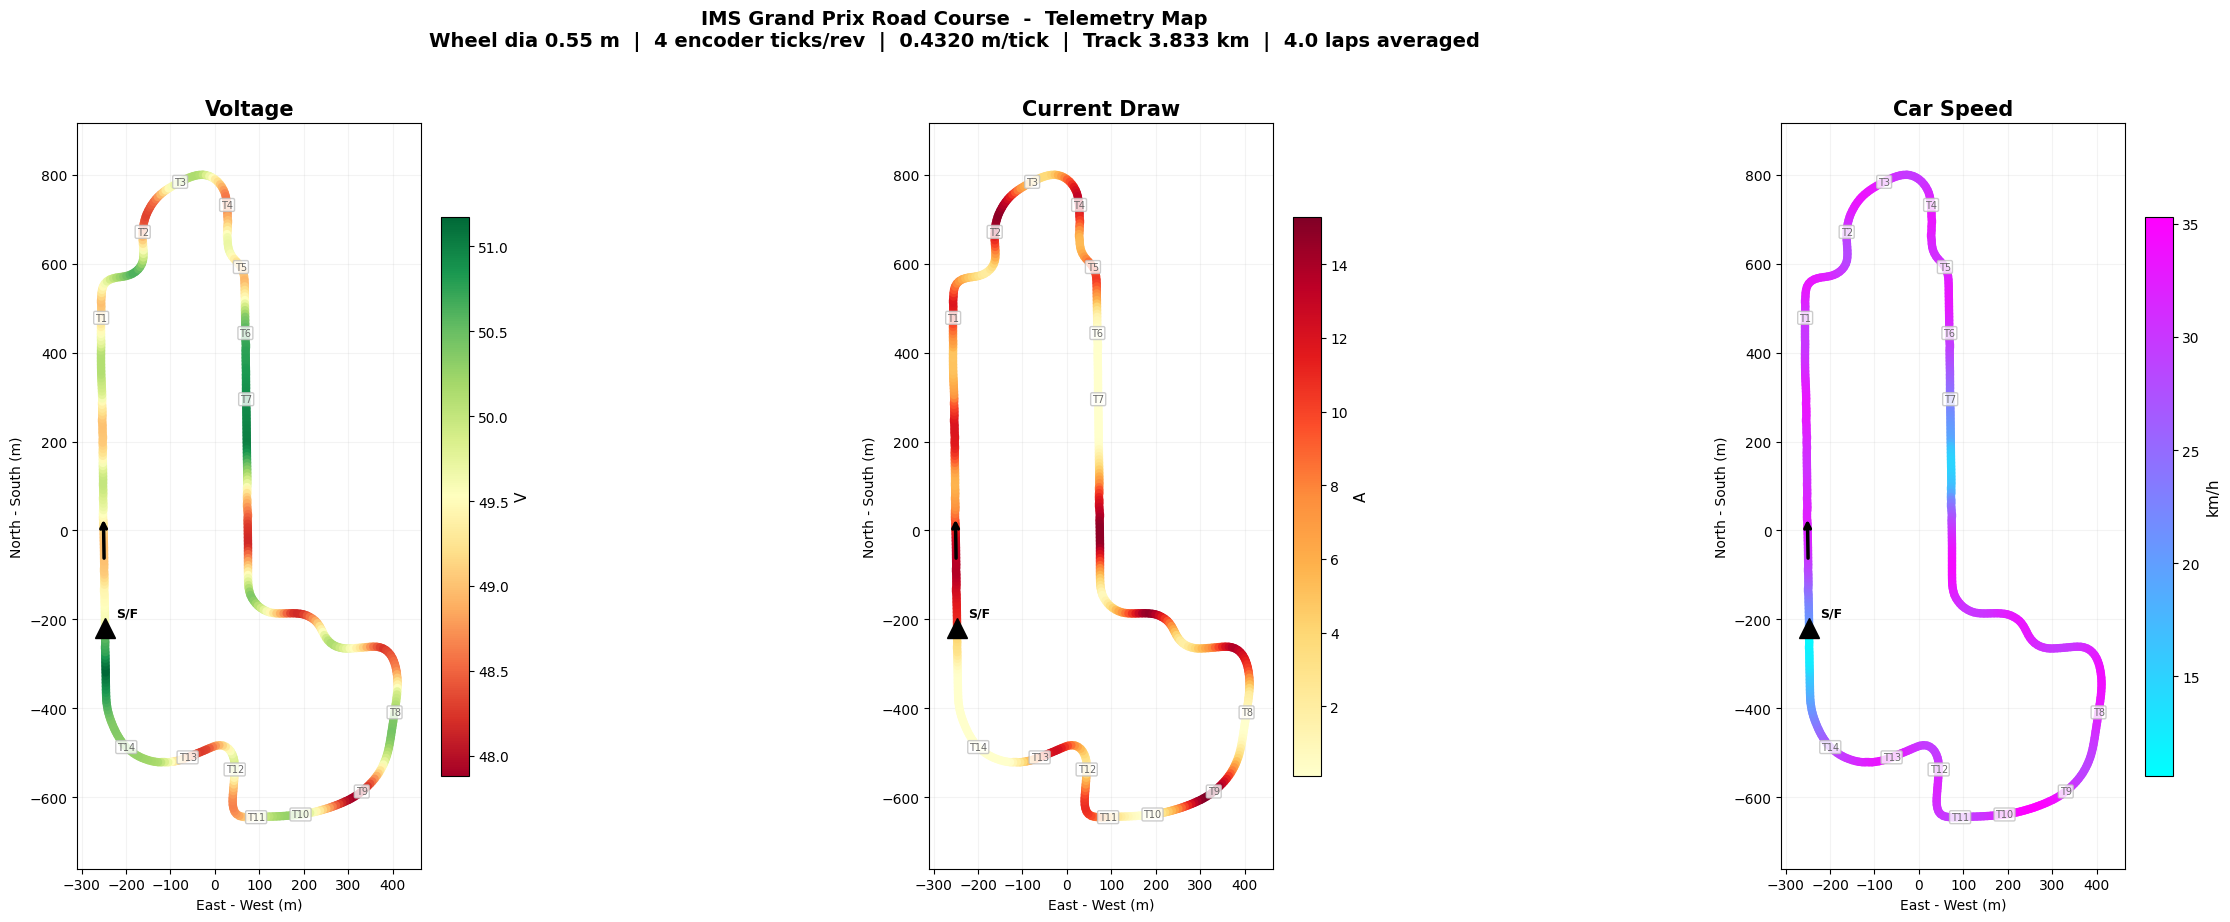

Saved: ims_telemetry_map.png


In [63]:
# ── Bin telemetry by track position (both laps averaged) ──
N_BINS = 500
bin_edges = np.linspace(0, TRACK_LEN, N_BINS + 1)
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

def bin_on_track(positions, values):
    """Average telemetry values into track-distance bins and smooth."""
    bin_idx = np.clip(np.digitize(positions, bin_edges) - 1, 0, N_BINS - 1)
    binned = pd.Series(values).groupby(bin_idx).mean().reindex(range(N_BINS))
    binned = binned.interpolate().bfill().ffill()
    return binned.rolling(15, center=True, min_periods=1).mean().values

def bin_std_on_track(positions, values):
    """Std-dev of values per track-distance bin (shows inter-lap variance)."""
    bin_idx = np.clip(np.digitize(positions, bin_edges) - 1, 0, N_BINS - 1)
    binned = pd.Series(values).groupby(bin_idx).std().reindex(range(N_BINS))
    binned = binned.interpolate().bfill().ffill()
    return binned.rolling(15, center=True, min_periods=1).mean().values

v_bin  = bin_on_track(df['TrackPos'].values, df['Voltage_V'].values)
c_bin  = bin_on_track(df['TrackPos'].values, df['Current_A'].values)
s_bin  = bin_on_track(df['TrackPos'].values, df['Speed_kph'].values)
a_bin  = bin_on_track(df['TrackPos'].values, accel.values)                # avg accel per section
sv_bin = bin_std_on_track(df['TrackPos'].values, df['Speed_kph'].values)  # speed std per section

# Map bin centres to track XY coordinates
bin_xy = np.array([dist_to_xy(d) for d in bin_mids])
points = bin_xy.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Turn label positions (approximate track distance in metres)
turn_info = [
    ('T1',  700), ('T2',  950), ('T3', 1100), ('T4', 1250),
    ('T5', 1400), ('T6', 1550), ('T7', 1700),
    ('T8', 2650), ('T9', 2850), ('T10', 3000),
    ('T11', 3100), ('T12', 3250), ('T13', 3400), ('T14', 3550),
]

# ── Three-panel track map ──
fig, axes = plt.subplots(1, 3, figsize=(27, 9))

panels = [
    (v_bin, 'Voltage',      'V',    'RdYlGn'),
    (c_bin, 'Current Draw', 'A',    'YlOrRd'),
    (s_bin, 'Car Speed',    'km/h', 'cool'),
]

for ax, (vals, title, unit, cmap) in zip(axes, panels):
    norm = Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    lc = LineCollection(segments, cmap=cmap, norm=norm,
                        linewidths=6, capstyle='round')
    lc.set_array(vals[:-1])
    ax.add_collection(lc)

    cbar = fig.colorbar(lc, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label(unit, fontsize=11)

    sf = dist_to_xy(0)
    ax.plot(*sf, 'k^', ms=14, zorder=5)
    ax.annotate('S/F', sf, textcoords='offset points',
                xytext=(8, 8), fontsize=9, fontweight='bold')

    a1, a2 = dist_to_xy(150), dist_to_xy(250)
    ax.annotate('', xy=a2, xytext=a1,
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

    for lbl, d in turn_info:
        txy = dist_to_xy(d)
        ax.annotate(lbl, txy, fontsize=7, ha='center', va='center',
                    color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.15',
                              fc='white', ec='silver', alpha=0.8))

    ax.set_aspect('equal')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('East - West (m)')
    ax.set_ylabel('North - South (m)')
    ax.grid(True, alpha=0.15)
    ax.autoscale()
    ax.margins(0.08)

fig.suptitle(
    'IMS Grand Prix Road Course  -  Telemetry Map\n'
    f'Wheel dia {WHEEL_DIAM} m  |  {N_ENC} encoder ticks/rev  |  '
    f'{DIST_PER_TICK:.4f} m/tick  |  Track {TRACK_LEN/1000:.3f} km  |  '
    f'{n_laps:.1f} laps averaged',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('ims_telemetry_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ims_telemetry_map.png")

# Interactive Track Map — Per-Tick Slider
Drag the slider (or press play) to move the car around the real GPS track.  
Use the **Overlay** dropdown to switch the coloured metric behind the car.

In [64]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# ── Load real GPS track ──
track_gps = pd.read_csv('sem-us-2022-track_coordinates.csv')
track_lat = track_gps.Latitude.values
track_lon = track_gps.Longitude.values

# Cumulative distance along GPS centreline (Haversine)
R_EARTH = 6_371_000  # metres
dlat = np.radians(np.diff(track_lat))
dlon = np.radians(np.diff(track_lon))
hav = (np.sin(dlat / 2) ** 2 +
       np.cos(np.radians(track_lat[:-1])) *
       np.cos(np.radians(track_lat[1:])) *
       np.sin(dlon / 2) ** 2)
track_arc = np.zeros(len(track_lat))
track_arc[1:] = np.cumsum(R_EARTH * 2 * np.arctan2(np.sqrt(hav), np.sqrt(1 - hav)))
GPS_LEN = track_arc[-1]

print(f"GPS track: {len(track_lat)} pts, {GPS_LEN:.0f} m")

# ── Map every telemetry sample → GPS position ──
gps_d   = (df['TrackPos'].values / TRACK_LEN) * GPS_LEN
gps_idx = np.clip(np.searchsorted(track_arc, gps_d), 0, len(track_lat) - 1)
car_lat = track_lat[gps_idx]
car_lon = track_lon[gps_idx]

# Map the 500 bins (from previous cell) → GPS for the coloured overlay
bin_gps_d   = (bin_mids / TRACK_LEN) * GPS_LEN
bin_gps_idx = np.clip(np.searchsorted(track_arc, bin_gps_d), 0, len(track_lat) - 1)
ov_lat = track_lat[bin_gps_idx]
ov_lon = track_lon[bin_gps_idx]

print(f"Mapped {len(car_lat)} telemetry samples to GPS coords")

GPS track: 3833 pts, 3833 m
Mapped 34801 telemetry samples to GPS coords


In [65]:
# ── Build plotly map + ipywidgets slider ──

fig = go.FigureWidget()

# Trace 0 — track outline (dark grey)
fig.add_trace(go.Scattermap(
    lat=track_lat, lon=track_lon,
    mode='lines',
    line=dict(color='#444', width=6),
    hoverinfo='skip', showlegend=False,
))

# Trace 1 — coloured metric overlay (dots along centreline)
fig.add_trace(go.Scattermap(
    lat=ov_lat, lon=ov_lon,
    mode='markers',
    marker=dict(
        size=6, color=s_bin,
        colorscale='Viridis',
        cmin=0, cmax=float(df['Speed_kph'].max()),
        showscale=True,
        colorbar=dict(title=dict(text='km/h'), x=1.0, len=0.5, y=0.75),
    ),
    hoverinfo='skip', showlegend=False,
))

# Trace 2 — car position (large red dot)
fig.add_trace(go.Scattermap(
    lat=[float(car_lat[0])], lon=[float(car_lon[0])],
    mode='markers',
    marker=dict(size=18, color='red'),
    showlegend=False,
))

fig.update_layout(
    map=dict(
        style='open-street-map',
        center=dict(lat=float(track_lat.mean()), lon=float(track_lon.mean())),
        zoom=14.5,
    ),
    margin=dict(l=0, r=0, t=0, b=0),
    height=600,
)

# ── Widgets ──
slider = widgets.IntSlider(
    value=0, min=0, max=len(df) - 1, step=1,
    description='Sample:',
    continuous_update=True,
    layout=widgets.Layout(width='85%'),
    style={'description_width': '55px'},
)

play_btn = widgets.Play(
    value=0, min=0, max=len(df) - 1, step=20,
    interval=30, description='Play',
)
widgets.jslink((play_btn, 'value'), (slider, 'value'))

metric_dd = widgets.Dropdown(
    options=['Speed', 'Current', 'Voltage', 'Acceleration', 'Speed Variance'],
    value='Speed',
    description='Overlay:',
    style={'description_width': '55px'},
    layout=widgets.Layout(width='180px'),
)

info_html = widgets.HTML()

# Metric config:  (binned_values, colorscale, cmin, cmax, unit)
_metric_cfg = {
    'Speed':   (s_bin, 'Viridis', 0, float(df['Speed_kph'].max()), 'km/h'),
    'Current': (c_bin, 'YlOrRd',  0, float(df['Current_A'].max()),  'A'),
    'Voltage': (v_bin, 'RdYlGn',  float(df['Voltage_V'].min()),
                float(df['Voltage_V'].max()), 'V'),
    'Acceleration':   (a_bin,  'RdBu_r',  float(np.nanmin(a_bin)),
                       float(np.nanmax(a_bin)), 'm/s²'),
    'Speed Variance': (sv_bin, 'hot_r',   0,
                       float(np.nanmax(sv_bin)), 'σ km/h'),
}

def _on_metric(change):
    vals, cs, lo, hi, unit = _metric_cfg[change['new']]
    with fig.batch_update():
        fig.data[1].marker.color      = vals
        fig.data[1].marker.colorscale = cs
        fig.data[1].marker.cmin       = lo
        fig.data[1].marker.cmax       = hi
        fig.data[1].marker.colorbar.title.text = unit

metric_dd.observe(_on_metric, names='value')

def _on_tick(change):
    i = change['new']
    with fig.batch_update():
        fig.data[2].lat = [float(car_lat[i])]
        fig.data[2].lon = [float(car_lon[i])]

    spd  = df['Speed_kph'].iloc[i]
    volt = df['Voltage_V'].iloc[i]
    cur  = df['Current_A'].iloc[i]
    pwr  = volt * cur
    t_min = df['TimePlot'].iloc[i]
    dist  = df['Distance_m'].iloc[i]
    lap   = int(dist / TRACK_LEN) + 1
    thr   = df['Throttle'].iloc[i]

    info_html.value = (
        '<div style="font-family:\'Courier New\',monospace;font-size:15px;'
        'padding:12px;background:linear-gradient(135deg,#1a1a2e,#16213e);'
        'color:#eee;border-radius:10px;display:flex;gap:24px;flex-wrap:wrap;'
        'align-items:center;">'
        f'<div><span style="color:#888">TIME</span><br>'
        f'<b style="font-size:18px">{t_min:.2f} min</b></div>'
        f'<div><span style="color:#888">DISTANCE</span><br>'
        f'<b style="font-size:18px">{dist:.0f} m</b></div>'
        f'<div><span style="color:#888">LAP</span><br>'
        f'<b style="font-size:18px">{lap}</b></div>'
        '<div style="border-left:1px solid #444;padding-left:20px">'
        f'<span style="color:#4CAF50">VOLTAGE</span><br>'
        f'<b style="font-size:18px">{volt:.1f} V</b></div>'
        f'<div><span style="color:#FF9800">CURRENT</span><br>'
        f'<b style="font-size:18px">{cur:.1f} A</b></div>'
        f'<div><span style="color:#E91E63">POWER</span><br>'
        f'<b style="font-size:18px">{pwr:.1f} W</b></div>'
        '<div style="border-left:1px solid #444;padding-left:20px">'
        f'<span style="color:#2196F3">SPEED</span><br>'
        f'<b style="font-size:18px">{spd:.1f} km/h</b></div>'
        f'<div><span style="color:#9C27B0">THROTTLE</span><br>'
        f'<b style="font-size:18px">{thr}</b></div>'
        '</div>'
    )

slider.observe(_on_tick, names='value')
_on_tick({'new': 0})

# ── Assemble and display ──
controls = widgets.HBox(
    [play_btn, slider, metric_dd],
    layout=widgets.Layout(align_items='center', gap='8px'),
)
display(widgets.VBox([fig, controls, info_html]))

    'data': [{'hoverinfo': 'skip',
              'lat': {'bdata': ('mdTQBmDlQ0Dg…